# 1. Introduction

## 1.1 Genomic prediction and polygenic scores (PGSs)

**What are PGSs and why are they interesting?**

A growing area withing human genetics is the examining how well can we predict human traits, such as cholesterol levels or disease risk, from genetic data alone. This is interesting from a biological perspective (how much of this trait is genetic? in what manner do the genetics influence this trait?) as well as for the clinic (can we identify high risk individuals before symptoms appear?). 

The current approach to this is using a polygenic score (PGS), which is a single number summarizing the total/combined effect of multiple genetic variants on a single trait.

*Some terminology:*

- **PGS (polygenic score)**: Generally used as the umbrella term that can be applied to any trait, whether continuous (HDL cholesterol, BMI, height) or binary (coronary artery disease, type 2 diabetes, eye color).
- **PRS (polygenic risk score)**: Generally referes specifically to *disease risk*.

It's useful to be aware of both of these terms as they both appear in the literature, and are often used interchangeably (e.g. sometimes you might see PRS used to refer to height, which is perhaps not 100% precise).

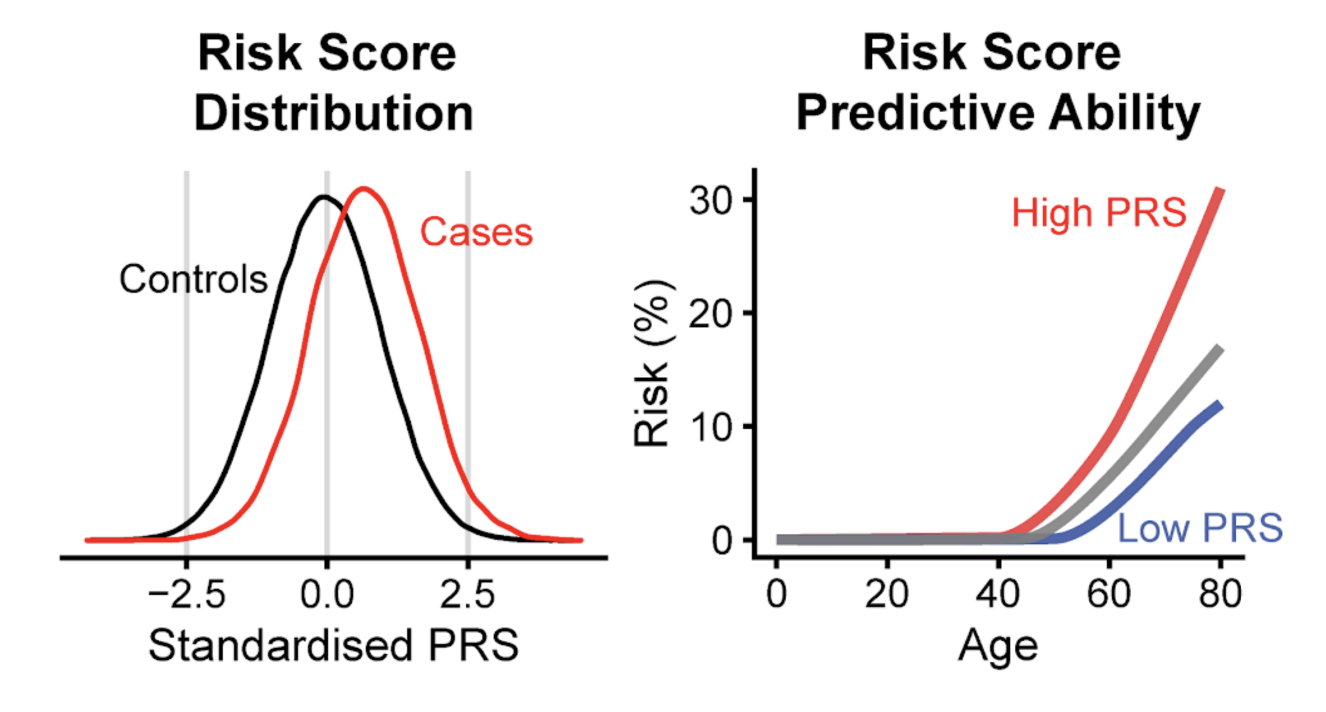

In [40]:
from IPython.display import Image, display
display(Image(filename="../docs/static/figures/PGS_Illustration.png", width=600))

**How do we compute PGSs?**

By now you are likely quite familiar with GWAS, and you know that it gives you, for each variant in the genome, an estimate effect size ($\beta$, the regression coefficient), describing how much each allele copy affects the phenotype.

| Variant | Effect allele | $\beta$ (effect size) | Individual's dosage |
|---------|---------------|------------------------|---------------------|
| SNP 1   | A             | $+0.15$                | 2                   |
| SNP 2   | T             | $-0.08$                | 1                   |
| SNP 3   | G             | $+0.22$                | 0                   |
| SNP 4   | C             | $+0.05$                | 2                   |
| SNP 5   | A             | $-0.12$                | 1                   |

Dosage here refers to the number of effect alleles an individual carries for a given variant. Now, if we have the actual genotypes for individuals, we can for example compute the score via a weighted sum of the dosages and the effect sizes:

In [42]:
import numpy as np
betas = np.array([0.15, -0.08, 0.22, 0.05, -0.12])
dosage = np.array([2, 1, 0, 2, 1])
print(f"PGS = {(betas * dosage).sum():.2f}")

PGS = 0.20


*In reality it's not quite this simple.* Real PGSs might use millions of variants, and complications include:

- **Linkage disequilibrium (LD)**: Nearby variants are correlated and might be tagging a single causal signal. Summing up all of them double counts that actual affect.
- **Noisy effect sizes:** Many GWAS $\beta$ estimates are small and noisy. Including them almost certainly hurts predictive performance, it's likely better to either need to downweight or drop them.

These, and other issues, have driven the development of a whole family of advanced and useful PGS methods, which differ in the way they handle the issues above:

- Clumping + thresholding (C+T)
- LDpred / LDpred2
- PRS-CS

!TODO: cite/link to methods

**Challenges with PGS**

!TODO (ancestry bias, transferability, etc)

**Additional resources**

- [Wikipedia article on polygenic scores](https://en.wikipedia.org/wiki/Polygenic_score)
- [Tutorial: a guide to performing polygenic risk score analyses](https://www.nature.com/articles/s41596-020-0353-1)
- [Polygenic risk scores: from research tools to clinical instruments ](https://link.springer.com/article/10.1186/s13073-020-00742-5)
- [The Polygenic Score Catalog as an open database for reproducibility and systematic evaluation](https://www.nature.com/articles/s41588-021-00783-5)

## 1.2 From PGS to foundation models

## 1.3 What you will do here

- Overview of what we are doing
- Information and link to PennCATH.

# 2. Data setup

In [1]:
# !uv pip install gdown
# !uv pip install umap-learn

import gdown

In [ ]:
model_zip_id = "1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W"
output = "../reference_data/models/"
gdown.download(id=model_zip_id, output=output)

In [3]:
penncath_hg38_id = "1d1phne1USPa7gkj7LOneyFH9zcGexvHs"
output = "../reference_data/"
gdown.download(id=penncath_hg38_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs
From (redirected): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs&confirm=t&uuid=479fc4c7-1272-4930-9227-427ea89da96d
To: /Users/txb777/Projects/phd/integrative_post_gwas_methods_course/reference_data/penncat_hg38.zip
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143M/143M [00:01<00:00, 73.9MB/s]


'../reference_data/penncat_hg38.zip'

In [4]:
!unzip -o ../reference_data/penncat_hg38.zip -d ../reference_data

Archive:  ../reference_data/penncat_hg38.zip
  inflating: ../reference_data//penncath_hg38/penncath.csv  
  inflating: ../reference_data//penncath_hg38/penncath.bim  
  inflating: ../reference_data//penncath_hg38/penncath.bed  
  inflating: ../reference_data//penncath_hg38/penncath.fam  


# 3. Prediction

Notice above how we downloaded this perhaps weirdly named `ext_d_inf_moe_general_16L-FUS_multitask.zip` file? These are trained neural network weights, where the model was trained on the UK Biobank to predict hundreds of traits from genotype data (e.g. anthropometrics, diseases, lipids, etc.). After downloading this file, and preparing our individual level genotype data, we can pass both of them to the `eirpredict` command that predicts into the PennCATH dataset.

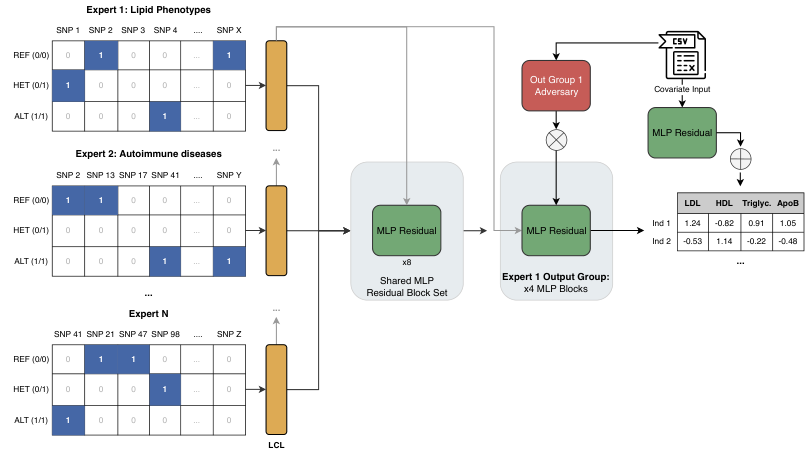

In [7]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../docs/static/figures/eir_fm_architecture.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

**Note**: The command just prints might take a couple of seconds before it starts to print anything on the screen as the necessary deep-learning software libraries are loaded. 

In [5]:
!eirautogppredict --genotype_data_path ../reference_data/penncath_hg38 --packed_experiment_path ../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip --output_folder ../output

09:44:48 - WARNING - eir_auto_gp.predict.prepare_data - Dropping 1 ambiguous (palindromic) SNPs.
09:44:48 - INFO - eir_auto_gp.predict.prepare_data - Matching Stats: Exact=31513, Reversal=15743, StrandFlip=31404, Flip+Rev=15868
09:44:48 - INFO - eir_auto_gp.predict.prepare_data - Applying PLINK pre-filtering (94528/861221 SNPs matched)
09:44:48 - INFO - eir_auto_gp.predict.prepare_data - Created extract list with 94528 unique VAR_IDs from 94528 matched SNPs
09:44:48 - INFO - eir_auto_gp.predict.prepare_data - Running: plink2 --bfile ../reference_data/penncath_hg38/penncath --extract ../output/data/plink_temp_ba527966/extract_list.txt --make-bed --keep-allele-order --out ../output/data/plink_temp_ba527966/filtered
09:44:49 - INFO - eir_auto_gp.predict.prepare_data - PLINK filtering completed successfully
09:44:49 - INFO - eir_auto_gp.predict.prepare_data - PLINK stdout: PLINK v2.0.0-a.6.4 M1 (6 Dec 2024)                 cog-genomics.org/plink/2.0/
(C) 2005-2024 Shaun Purcell, Christophe

# 4. Analysis

!TODO: What we are doing in the analysis section.

## 4.1 Imports and setup

In [8]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

In [9]:
def load_trait_csv(path: Path) -> pd.Series:
  df = pd.read_csv(path).set_index("ID")
  trait = path.stem
  prob1 = [c for c in df.columns if c.endswith("Ensemble Prob 1")]
  if prob1:
      s = df[prob1[0]].rename(trait)
      s.attrs["kind"] = "binary"
      return s
  ensemble = [c for c in df.columns if re.fullmatch(rf"{re.escape(trait)} Ensemble", c)]
  if not ensemble:
      raise ValueError(f"No ensemble column found in {path.name}: {list(df.columns)}")
  s = df[ensemble[0]].rename(trait)
  s.attrs["kind"] = "continuous"
  return s

## 4.2 Loading in the predictions

When we use the `eirpredict` command, the model generates prediction for each individual, for each target phenotype the model was originally trained for. Each predicted phenotype results in a single `.csv` file saved on the disk. The `... Ensemble` column is the average of training multiple folds (i.e. slightly different versions of the model, which allows estimating uncertainty in any given prediction among other things), since we only have a single fold in this case, the `... Ensemble` column is the same as the `Fold 0` column.

In [14]:
!ls "../output/results" | head

Alanine_aminotransferase.csv
Albumin_BIOCH.csv
Alkaline_phosphatase.csv
Apolipoprotein_A.csv
Apolipoprotein_A1.csv
Apolipoprotein_B_BIOCH.csv
Apolipoprotein_B_METAB.csv
Aspartate_aminotransferase.csv
Average_Diameter_for_HDL_Particles.csv
Average_Diameter_for_VLDL_Particles.csv


In [15]:
!head "../output/results/Alanine_aminotransferase.csv"

ID,Alanine_aminotransferase Fold 0,Alanine_aminotransferase Ensemble
10002,22.542772,22.542772
10004,28.100965,28.100965
10005,22.484835,22.484835
10007,23.97966,23.97966
10008,26.343996,26.343996
10009,26.6976,26.6976
10010,21.769466,21.769466
10011,22.51627,22.51627
10012,22.866842,22.866842


The code below essentially gathers upp all these `.csv` files for all the predicted phenotypes into a single data frame, so for each of the 1401 individuals in the PennCATH dataset, we end up with 315 (237 continuous and 78 binary) "features" (i.e., predicted phenotypes).

In [10]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

preds = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {preds.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")
display(preds.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542772,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.537926,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361750,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.547020,76.31497,6.289234,52.096508,23.333853,37.992416
10005,22.484835,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930590,76.097400,75.78765,6.923183,51.953293,26.081810,37.976200
10007,23.979660,45.518280,87.363420,1.639348,1.566334,1.016251,0.852204,24.755083,9.717244,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.782000,70.52157,6.385489,49.508488,22.894983,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538030,78.507370,78.36777,6.650043,52.501266,23.214048,38.252075


## 4.3 Loading the actual, measured PennCATH labels

Here we load in the *actual* measured phenotypes in the PennCATH, which we will compare and analyze with the predicted values from the UKB trained model.

In [16]:
labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {labels.shape}")
display(labels.head())

labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


## 4.4 Merging true PennCATH labels with relevant predictions

Notice above the real, measured phenotypes in PennCATH include Triglycerides (`tg`), HDL Cholesterol (`hdl`) and LDL Cholesterol (`ldl`). Lucily, we have the same phenotypes (albeit named slightly differently) in the model trained in the UKB, which allows us to directly compare the predictions for these 3 phenotypes to the real values. 

In [18]:
continuous_traits = {
    'TG': 'Triglycerides',
    'HDL': 'HDL Cholesterol',
    'LDL': 'LDL Cholesterol'
}

binary_traits = {
    'CAD': 'Coronary Artery Disease'
}

In [27]:
rename_preds = {
    'I25': 'CAD_pred',
    'Total_Triglycerides': 'TG_pred',
    'HDL_cholesterol': 'HDL_pred',
    'LDL_Cholesterol': 'LDL_pred'
}

rename_true = {
    'CAD': 'CAD_true',
    'tg': 'TG_true',
    'hdl': 'HDL_true',
    'ldl': 'LDL_true'
}

preds_copy = preds.reset_index()
preds_copy = preds_copy[['ID'] + list(rename_preds.keys())].copy()
preds_renamed = preds_copy.rename(columns=rename_preds)
true_renamed = labels.rename(columns=rename_true)

df_real_final = pd.merge(preds_renamed, true_renamed, on='ID', how='inner')
print(f"merged: {df_real_final.shape}")
display(df_real_final.head())

merged: (1401, 11)


,ID,CAD_pred,TG_pred,HDL_pred,LDL_pred,CAD_true,sex,age,TG_true,HDL_true,LDL_true
0,10002,0.299964,1.445587,1.431592,1.888146,1,1,60,NaN,NaN,NaN
1,10004,0.366859,1.230927,1.444633,1.623983,1,2,50,55.0,23.0,75.0
2,10005,0.418133,1.732881,1.349207,1.733176,1,1,55,105.0,37.0,69.0
3,10007,0.428991,1.272115,1.598767,1.763022,1,1,52,314.0,54.0,108.0
4,10008,0.453609,1.419624,1.304491,1.781938,1,1,58,161.0,40.0,94.0


## 4.5 Evaluation of Continuous Traits

So, as mentioned above, for the first analysis, we will compare how some of the predicted phenotypes from the UKB model above match 

!TODO: Indicate why we need the Z-score here (i.e. Unit conversion (Converted): mmol/L → mg/dL).

In [22]:
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve, auc
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

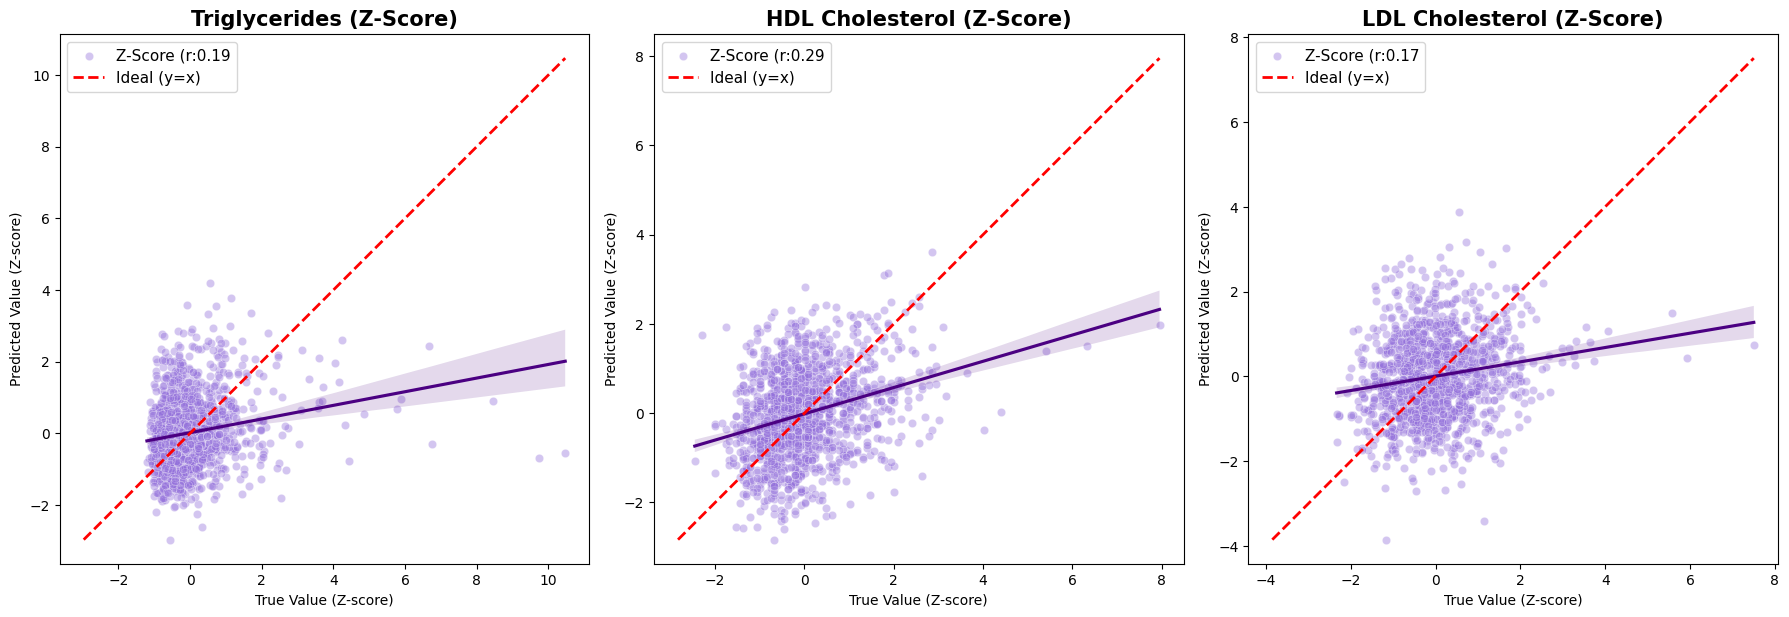

In [28]:
df_zscore = df_real_final.copy()
scaler = StandardScaler()

for trait in continuous_traits.keys():
    df_zscore[f'{trait}_true_z'] = scaler.fit_transform(df_zscore[[f'{trait}_true']])
    df_zscore[f'{trait}_pred_z'] = scaler.fit_transform(df_zscore[[f'{trait}_pred']])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, trait in enumerate(continuous_traits.keys()):
    cols = [f'{trait}_true_z', f'{trait}_pred_z']
    valid_data = df_zscore[cols].dropna()
    
    y_true_z = valid_data[f'{trait}_true_z']
    y_pred_z = valid_data[f'{trait}_pred_z']
    
    ax = axes[i]
    
    corr_z, _ = pearsonr(y_true_z, y_pred_z)
    
    label_z = f'Z-Score (r:{corr_z:.2f}'
    
    sns.scatterplot(x=y_true_z, y=y_pred_z, alpha=0.4, ax=ax, label=label_z, color='mediumpurple')
    sns.regplot(x=y_true_z, y=y_pred_z, scatter=False, ax=ax, color='indigo', )
 
    all_vals = pd.concat([y_true_z, y_pred_z])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
    
    ax.set_title(f'{continuous_traits[trait]} (Z-Score)', fontsize=15, fontweight='bold')
    ax.set_xlabel('True Value (Z-score)')
    ax.set_ylabel('Predicted Value (Z-score)')
    
    ax.legend(loc='upper left', fontsize=11)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

## Checking for counfounding - how much do predictions improve over a baseline?

As you might know, GWAS (and by extension PGS and PRS) can be famously tricky due to confounders like ancestry bias or population stratification. If our model has e.g. learned a proxy for demographic variables in the UKB genetic data, and this bias is also reflected in PennCATH then it might seem like the model is effective at predicting Triglycerides from genetic data when when in reality, it is mostly just capturing the baseline differences in Triglycerides between males and females.

One way to check for this is to example how much the phenotype predictions *improve* over a baseline where we account for variables that 

**References:**

- [Apparent latent structure within the UK Biobank sample has implications for epidemiological analysis](https://www.nature.com/articles/s41467-018-08219-1) (discusses the importance of correcting for confounding, and how even the current approaches might not always be sufficient)
- [Tutorial: a guide to performing polygenic risk score analyses](https://www.nature.com/articles/s41596-020-0353-1) (besides being a great resource, discusses incremental R2)

!TODO: Add more citations/links to confounding examples

In [30]:
import statsmodels.formula.api as smf

df = df_real_final.copy()

for trait, full_name in continuous_traits.items():
    y_col = f"{trait}_true"
    prs_col = f"{trait}_pred"
    
    # Base Model (age + sex)
    formula_base = f"{y_col} ~ age + sex"
    model_base = smf.ols(formula=formula_base, data=df).fit()
    r2_base = model_base.rsquared * 100
    
    # Full Model
    formula_full = f"{y_col} ~ age + sex + {prs_col}"
    model_full = smf.ols(formula=formula_full, data=df).fit()
    r2_full = model_full.rsquared * 100
    
    # Delta R2
    delta_r2 = r2_full - r2_base
    
    # P-value for the PRS term in the full model
    p_val_prs = model_full.pvalues[prs_col]
    
    print(f"[{trait} - {full_name}]")
    print(f" - Base R2 (age, sex): {r2_base:.2f}%")
    print(f" - Full R2 (+ PRS)  : {r2_full:.2f}%")
    print(f" - Delta R2         : +{delta_r2:.2f}% (p-value: {p_val_prs:.2e})\n")

[TG - Triglycerides]
 - Base R2 (age, sex): 2.91%
 - Full R2 (+ PRS)  : 5.74%
 - Delta R2         : +2.84% (p-value: 5.02e-10)

[HDL - HDL Cholesterol]
 - Base R2 (age, sex): 15.60%
 - Full R2 (+ PRS)  : 22.24%
 - Delta R2         : +6.64% (p-value: 4.75e-25)

[LDL - LDL Cholesterol]
 - Base R2 (age, sex): 1.80%
 - Full R2 (+ PRS)  : 4.70%
 - Delta R2         : +2.89% (p-value: 6.39e-10)



## Evaluation of Binary Traits

Given that our model can somewhat predict the lipid phenotypes above, and it does seem to meaningfully improve over the age and sex covariate baselines, we can explore how well it predicts Coronary Artery Disease in PennCATH. For this, we use the I25 (which is the ICD10 code for [Chronic ischaemic heart disease](https://icd.who.int/browse10/2019/en#/I25)) disease prediction from the DL model. 

In typical ML scenarios, we often use metrics such as accuracy, F1 score etc to evaluate our models. However, in genetic prediction settings, we rarely use a hard classification threshold which is used in metrics such as accuracy (e.g. >50% prediction confidence a sample is "assigned" the positive label). Because overall prevalence for a disease like CAD might be extremely low in the cohort, setting a rigid cut-off might simply assign all individuals being "negative" - not very useful despite giving a "high accuracy" in a imbalanced dataset. Additionally, for most disease traits, genetic predisposition acts more on a continuous spectrum (i.e., it is not that having a given allele makes it certain that you get a given disease)

!TODO: Link to ROC-AUC and PR-AUC

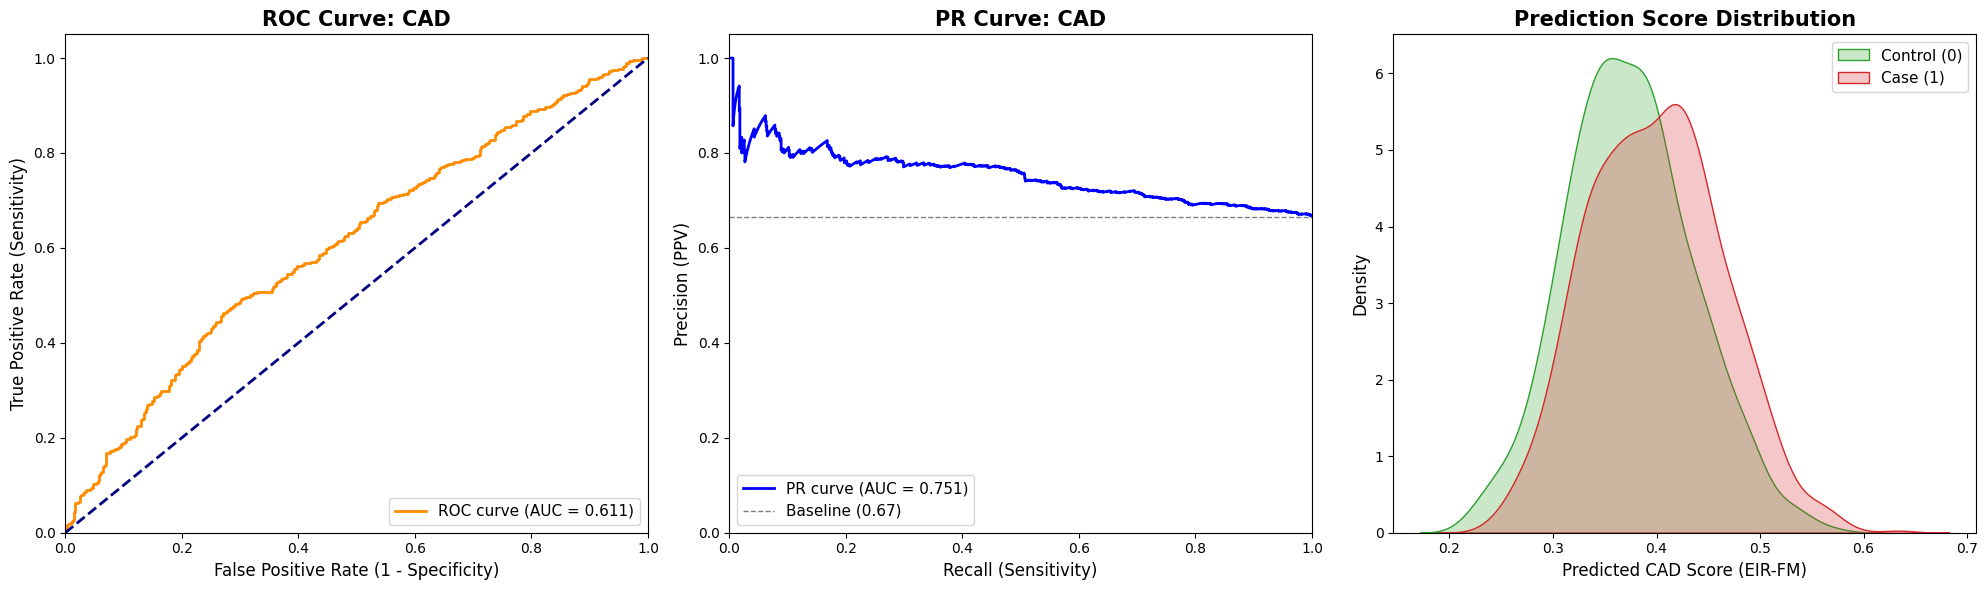

In [35]:
for trait, full_name in binary_traits.items():
    true_col = f'{trait}_true'
    pred_col = f'{trait}_pred'
    
    valid_data = df[[true_col, pred_col]].dropna()
    y_true = valid_data[true_col]
    y_score = valid_data[pred_col]
    
    roc_auc = roc_auc_score(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    axes[0].set_title(f'ROC Curve: {trait}', fontsize=15, fontweight='bold')
    axes[0].legend(loc="lower right", fontsize=11)

    axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    baseline = y_true.sum() / len(y_true)
    axes[1].axhline(y=baseline, color='gray', linestyle='--', lw=1, label=f'Baseline ({baseline:.2f})')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
    axes[1].set_ylabel('Precision (PPV)', fontsize=12)
    axes[1].set_title(f'PR Curve: {trait}', fontsize=15, fontweight='bold')
    axes[1].legend(loc="lower left", fontsize=11)

    sns.kdeplot(data=valid_data[valid_data[true_col] == 0][pred_col], 
                ax=axes[2], fill=True, color='#2ca02c', label='Control (0)')
    sns.kdeplot(data=valid_data[valid_data[true_col] == 1][pred_col], 
                ax=axes[2], fill=True, color='#d62728', label='Case (1)')
    axes[2].set_title(f'Prediction Score Distribution', fontsize=15, fontweight='bold')
    axes[2].set_xlabel(f'Predicted {trait} Score (EIR-FM)', fontsize=12)
    axes[2].set_ylabel('Density', fontsize=12)
    axes[2].legend(loc='upper right', fontsize=11)

    plt.tight_layout()
    plt.show()

In [15]:
for trait, full_name in binary_traits.items():
    y_col = f"{trait}_true"
    pred_col = f"{trait}_pred"

    # Base Model (age + sex)
    formula_base = f"{y_col} ~ age + sex"
    logit_base = smf.logit(formula=formula_base, data=df).fit(disp=0)
    
    auc_base = roc_auc_score(df[y_col], logit_base.predict(df))
    pseudo_r2_base = logit_base.prsquared * 100

    # Full Model
    formula_full = f"{y_col} ~ age + sex + {pred_col}"
    logit_full = smf.logit(formula=formula_full, data=df).fit(disp=0)
    
    auc_full = roc_auc_score(df[y_col], logit_full.predict(df))
    pseudo_r2_full = logit_full.prsquared * 100

    delta_auc = auc_full - auc_base
    delta_pseudo_r2 = pseudo_r2_full - pseudo_r2_base
    
    p_val_score = logit_full.pvalues[pred_col]

    print(f"[{trait} - {full_name}]")
    print(f" - Base Model (age, sex)")
    print(f"   * AUC: {auc_base:.4f} | Pseudo-R²: {pseudo_r2_base:.2f}%")
    
    print(f" - Full Model (+ {trait} Score)")
    print(f"   * AUC: {auc_full:.4f} | Pseudo-R²: {pseudo_r2_full:.2f}%")
    
    print(f" - Incremental Gain (Delta)")
    print(f"   * Delta AUC: +{delta_auc:.4f}")
    print(f"   * Delta R² : +{delta_pseudo_r2:.2f}% (p-value: {p_val_score:.2e})\n")

[CAD - Coronary Artery Disease]
 - Base Model (age, sex)
   * AUC: 0.7778 | Pseudo-R²: 20.51%
 - Full Model (+ CAD Score)
   * AUC: 0.7881 | Pseudo-R²: 21.96%
 - Incremental Gain (Delta)
   * Delta AUC: +0.0102
   * Delta R² : +1.45% (p-value: 5.84e-07)



## Clustering correlated traits

/Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


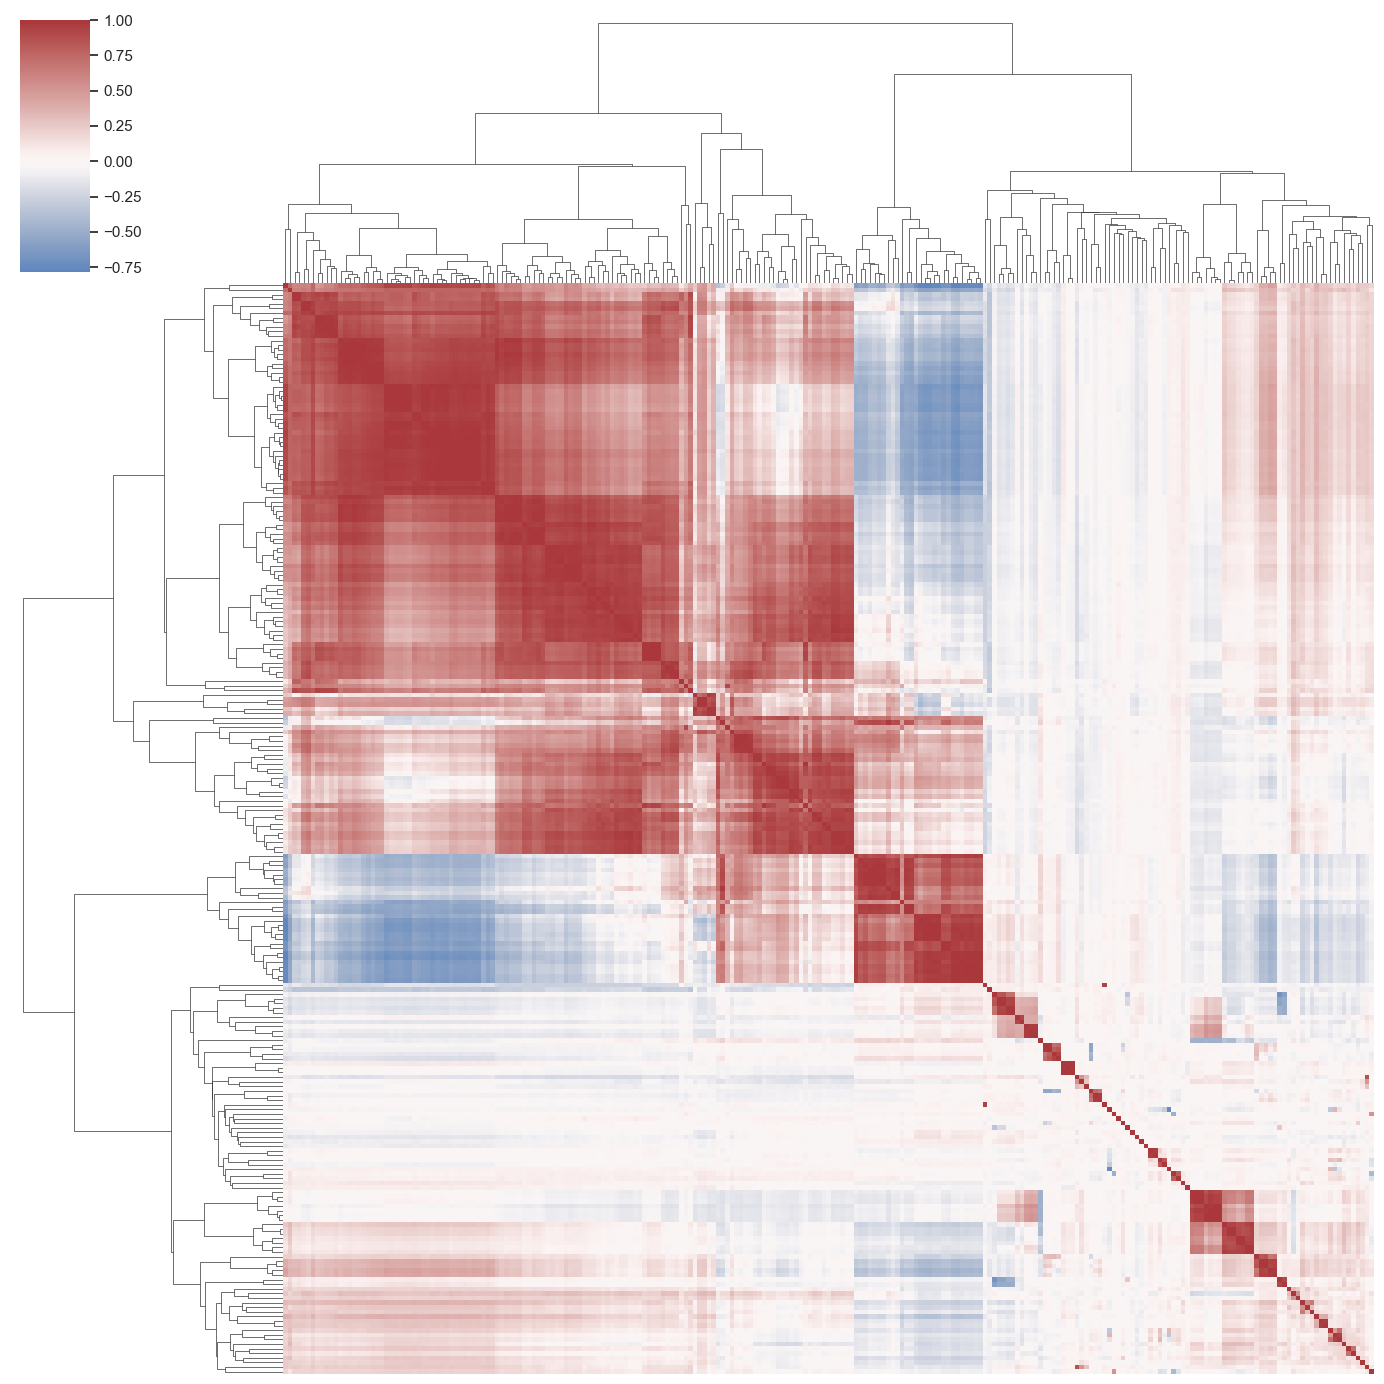

Continuous traits in correlation: 237


In [16]:
df = preds.copy()

cont_traits = trait_kind.index[trait_kind == "continuous"].tolist()
cont = df[cont_traits].apply(pd.to_numeric, errors="coerce")
cont = cont.loc[:, cont.std() > 0]
corr = cont.corr(method="spearman")

order = sns.clustermap(corr, cmap="vlag", center=0, figsize=(14, 14),
                    xticklabels=False, yticklabels=False).dendrogram_row.reordered_ind
plt.show()
print(f"Continuous traits in correlation: {corr.shape[0]}")

In [17]:
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = (corr.where(mask).stack()
            .rename("spearman").reset_index()
            .rename(columns={"level_0": "trait_a", "level_1": "trait_b"}))
pairs["abs_r"] = pairs["spearman"].abs()
pairs.sort_values("abs_r", ascending=False).head(20)

,trait_a,trait_b,spearman,abs_r
27951,Weight_ANTHRO,Weight_IMPED,0.997179,0.997179
4328,Cholesterol_in_Large_HDL,Cholesteryl_Esters_in_Large_HDL,0.996765,0.996765
13564,Concentration_of_Very_Small_VLDL_Particles,Total_Lipids_in_Very_Small_VLDL,0.996750,0.996750
24926,Phospholipids_in_Very_Small_VLDL,Total_Lipids_in_Very_Small_VLDL,0.996470,0.996470
2766,Body_mass_index_BMI_ANTHRO,Body_mass_index_BMI_IMPED,0.996365,0.996365
12874,Concentration_of_Small_VLDL_Particles,Total_Lipids_in_Small_VLDL,0.996149,0.996149
6246,Cholesterol_in_Very_Large_HDL,Cholesteryl_Esters_in_Very_Large_HDL,0.996089,0.996089
4753,Cholesterol_in_Large_VLDL,Cholesterol_in_Very_Large_VLDL,0.995785,0.995785
23911,Phospholipids_in_Large_HDL,Total_Lipids_in_Large_HDL,0.995528,0.995528
24767,Phospholipids_in_Very_Large_HDL,Total_Lipids_in_Very_Large_HDL,0.995453,0.995453


## Cluster visualization

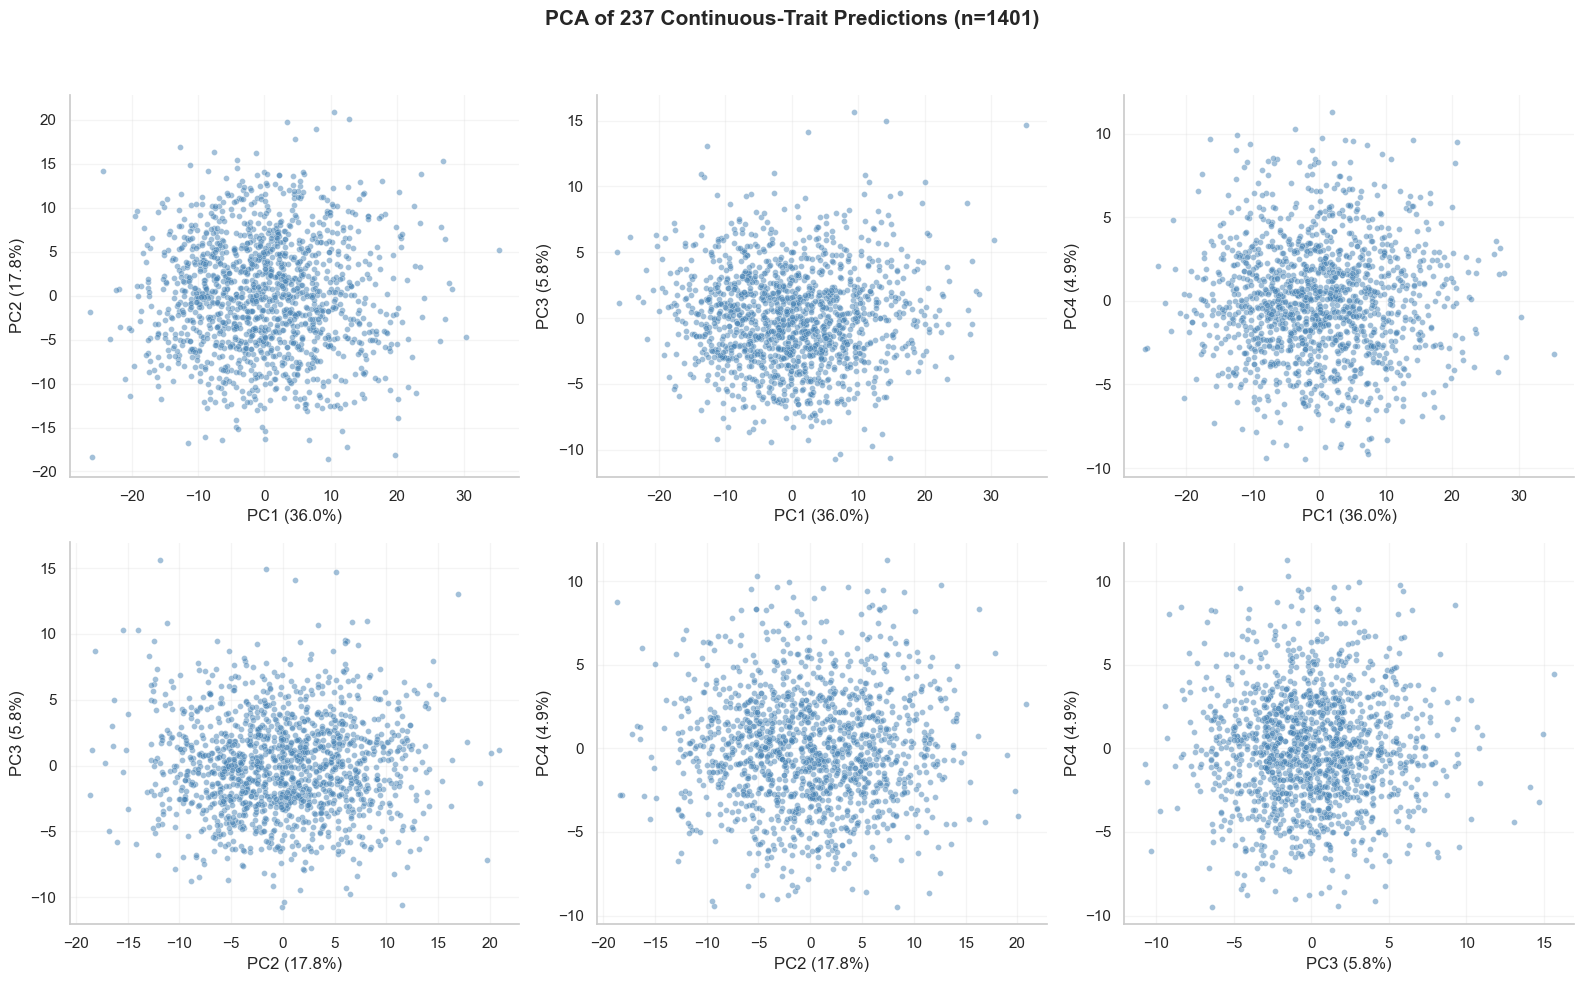

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import combinations

X_df = df[cont.columns].dropna(axis=1, thresh=int(0.95 * len(df)))
X = StandardScaler().fit_transform(X_df.values)

pca = PCA(n_components=4, random_state=0)
pcs = pca.fit_transform(X)
pc_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(4)], index=X_df.index)

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(pc_df[f"PC{i}"], pc_df[f"PC{j}"],
               s=18, alpha=0.5, linewidth=0.3,
               edgecolor="white", color='steelblue') 
    
    var_i = pca.explained_variance_ratio_[i-1]
    var_j = pca.explained_variance_ratio_[j-1]
    
    ax.set_xlabel(f"PC{i} ({var_i*100:.1f}%)")
    ax.set_ylabel(f"PC{j} ({var_j*100:.1f}%)")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

fig.suptitle(f"PCA of {X_df.shape[1]} Continuous-Trait Predictions (n={len(pc_df)})", 
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

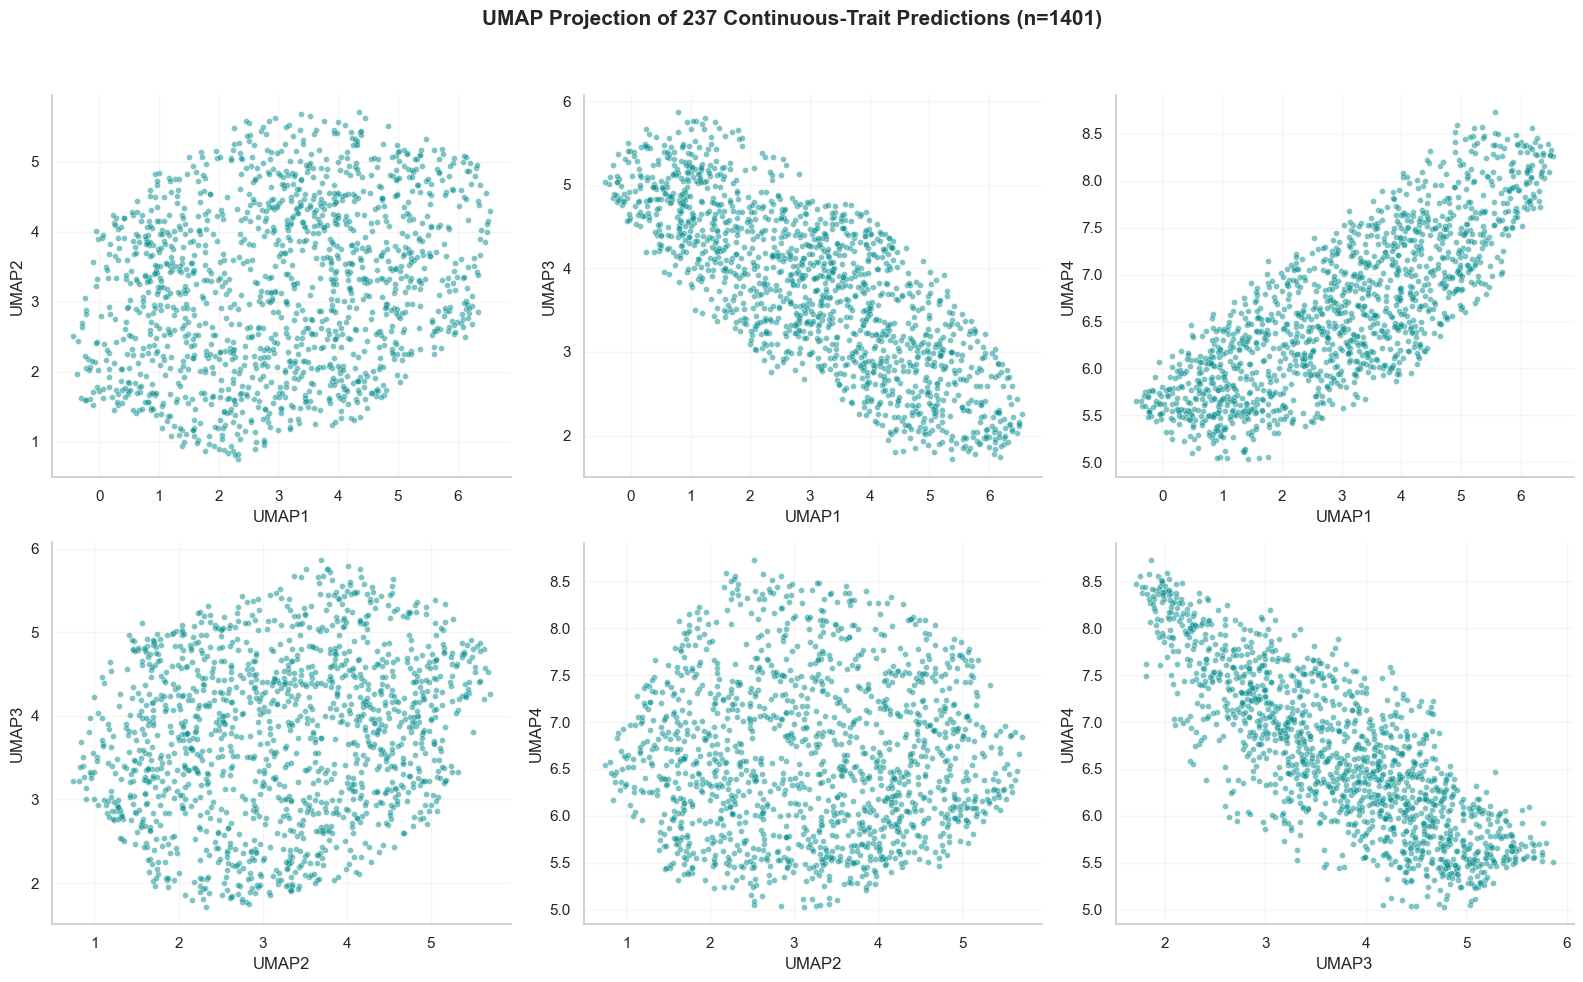

In [19]:
import umap

reducer = umap.UMAP(n_components=4, n_neighbors=30, min_dist=0.3,
                    metric="euclidean", random_state=42, n_jobs=1)

emb = reducer.fit_transform(X)
um_df = pd.DataFrame(emb, columns=[f"UMAP{i+1}" for i in range(4)], index=X_df.index)

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(um_df[f"UMAP{i}"], um_df[f"UMAP{j}"],
               s=18, alpha=0.5, linewidth=0.3,
               edgecolor="white", color='darkcyan')
    
    ax.set_xlabel(f"UMAP{i}")
    ax.set_ylabel(f"UMAP{j}")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

fig.suptitle(f"UMAP Projection of {X_df.shape[1]} Continuous-Trait Predictions (n={len(um_df)})",
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()